<a href="https://colab.research.google.com/github/jaizunT/deep_learning/blob/main/hw12/q_vae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 12

In this notebook, you will implement VAEs using a common framework.

The code is cloned from the following GitHub repo to the **temporary** directory of your Colab runtime, **WHICH WILL BE DELETED IF YOUR RUNTIME IS DISCONNECTED**. It is recommended to edit your code offline and paste it into the Colab environment.

In [1]:
!pip install --no-deps --upgrade IPython
%load_ext autoreload
%autoreload 2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.4/621.4 kB 15.2 MB/s eta 0:00:00
  Attempting uninstall: IPython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0


In [2]:
!git clone https://github.com/Berkeley-CS182/cs182hw12
%cd cs182hw12

Cloning into 'cs182hw12'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 9.12 KiB | 3.04 MiB/s, done.
/content/cs182hw12


### VAEs

##### (a) Implement the reparametrization trick in `sample_gaussian` in `utils.py`.

##### (b) Implement `negative_elbo_bound` in `models/vae.py`

##### (c) Run your VAE!

If you are using the shell, run:

```
python experiment.py --model vae
```

If you are on Colab, run the following cells:

In [7]:
from experiment import build_config_from_args, experiment

config = build_config_from_args(is_jupyter=True)
config.model = 'vae'
## TIP: For debugging, feel free to use a smaller iter_max to inspect loss and samples.
config.iter_max = 10000
print(config)
experiment(config)

Namespace(model='vae', num_latents=64, iter_max=10000, iter_save=500, runid=0, train=1, out_dir='results')
Model name: model=vae_z=64_run=0000
{'iter_max': 10000,
 'iter_save': 500,
 'model': 'vae',
 'num_latents': 64,
 'out_dir': 'results',
 'runid': 0,
 'train': 1}


100%|██████████| 10000/10000 [02:15<00:00, 73.78it/s]


********************************************************************************
LOG-LIKELIHOOD LOWER BOUNDS ON TEST SUBSET
********************************************************************************
NELBO: 98.99414825439453. KL: 24.500516891479492. Rec: 74.49359893798828
Saved visualization to results/generated_vae_10000.png


##### (d) Visualize samples from your VAE.

Find your visualizations in `results/generated_vae_<checkpoint_id>.png`

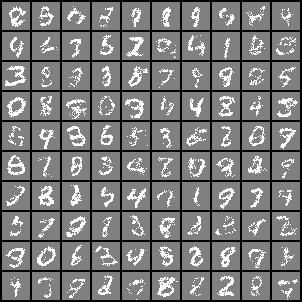

In [11]:
from IPython.display import Image, display

# Display the image generated after 10000 iterations
image_path = 'results/generated_vae_10000.png'
display(Image(filename=image_path))

In [19]:
modified_train_content = train_content.replace(
    "x_test = (self.model.sample_x(100) + 1) / 2.",
    "x_test = (self.model.sample_x(200) + 1) / 2."
)
modified_train_content = modified_train_content.replace(
    "x_test = x_test.reshape(100, 1, 28, 28)",
    "x_test = x_test.reshape(200, 1, 28, 28)"
)
modified_train_content = modified_train_content.replace(
    "%s/generated_%s_%04d.png' % (self.out_dir, self.model.name.split('_')[0][-3:], global_step), nrow=10)",
    "%s/generated_%s_%04d.png' % (self.out_dir, self.model.name.split('_')[0][-3:], global_step), nrow=20)"
)

with open('train.py', 'w') as f:
    f.write(modified_train_content)
print("Successfully modified train.py to generate 200 samples in a 10x20 grid.")


Successfully modified train.py to generate 200 samples in a 10x20 grid.


/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Running experiment in inference mode to generate samples:
Namespace(model='vae', num_latents=64, iter_max=10000, iter_save=500, runid=0, train=0, out_dir='results')
Model name: model=vae_z=64_run=0000
{'iter_max': 10000,
 'iter_save': 500,
 'model': 'vae',
 'num_latents': 64,
 'out_dir': 'results',
 'runid': 0,
 'train': 0}


100%|██████████| 10000/10000 [02:14<00:00, 74.48it/s]


********************************************************************************
LOG-LIKELIHOOD LOWER BOUNDS ON TEST SUBSET
********************************************************************************
NELBO: 98.99414825439453. KL: 24.500516891479492. Rec: 74.49359893798828
Saved visualization to results/generated_vae_10000.png


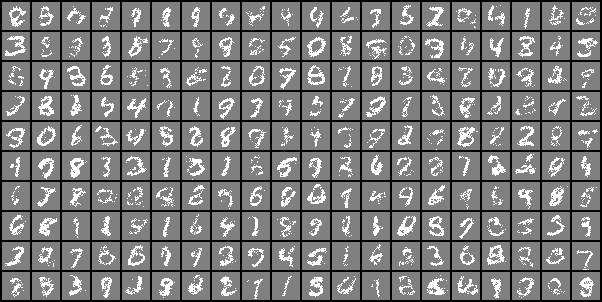

In [20]:
from experiment import build_config_from_args, experiment
from IPython.display import Image, display

# Build a config for inference/sampling
inference_config = build_config_from_args(is_jupyter=True)
inference_config.model = 'vae'
inference_config.train = 0  # Set to 0 for inference/sampling only
inference_config.iter_max = 10000 # Load model from 10000 iterations checkpoint
inference_config.runid = 0 # Ensure we load from the same run

print("Running experiment in inference mode to generate samples:")
print(inference_config)

# Run the experiment, which should now load the trained model and generate samples
# The output PNG will be generated with the specified iter_max
experiment(inference_config)

# Display the newly generated image
image_path = f'results/generated_vae_{inference_config.iter_max:04d}.png'
display(Image(filename=image_path))